<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/codealpha_tasks/blob/main/Task3_Handwritten_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Handwritten Character Recognition
### CodeAlpha Machine Learning Internship
**Objective:** Identify handwritten characters/digits using CNNs.  
**Dataset:** MNIST (digits 0-9, 70,000 images)  
**Model:** Convolutional Neural Network (CNN)  
**Extension:** EMNIST characters discussion


In [1]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"   GPUs available: {len(tf.config.list_physical_devices('GPU'))}")


✅ TensorFlow version: 2.19.0
   GPUs available: 1


In [2]:
# ─── Load MNIST Dataset ──────────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Image shape      : {X_train.shape[1:]}")
print(f"Pixel range      : [{X_train.min()}, {X_train.max()}]")
print(f"Classes          : {np.unique(y_train)}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60000
Test samples     : 10000
Image shape      : (28, 28)
Pixel range      : [0, 255]
Classes          : [0 1 2 3 4 5 6 7 8 9]


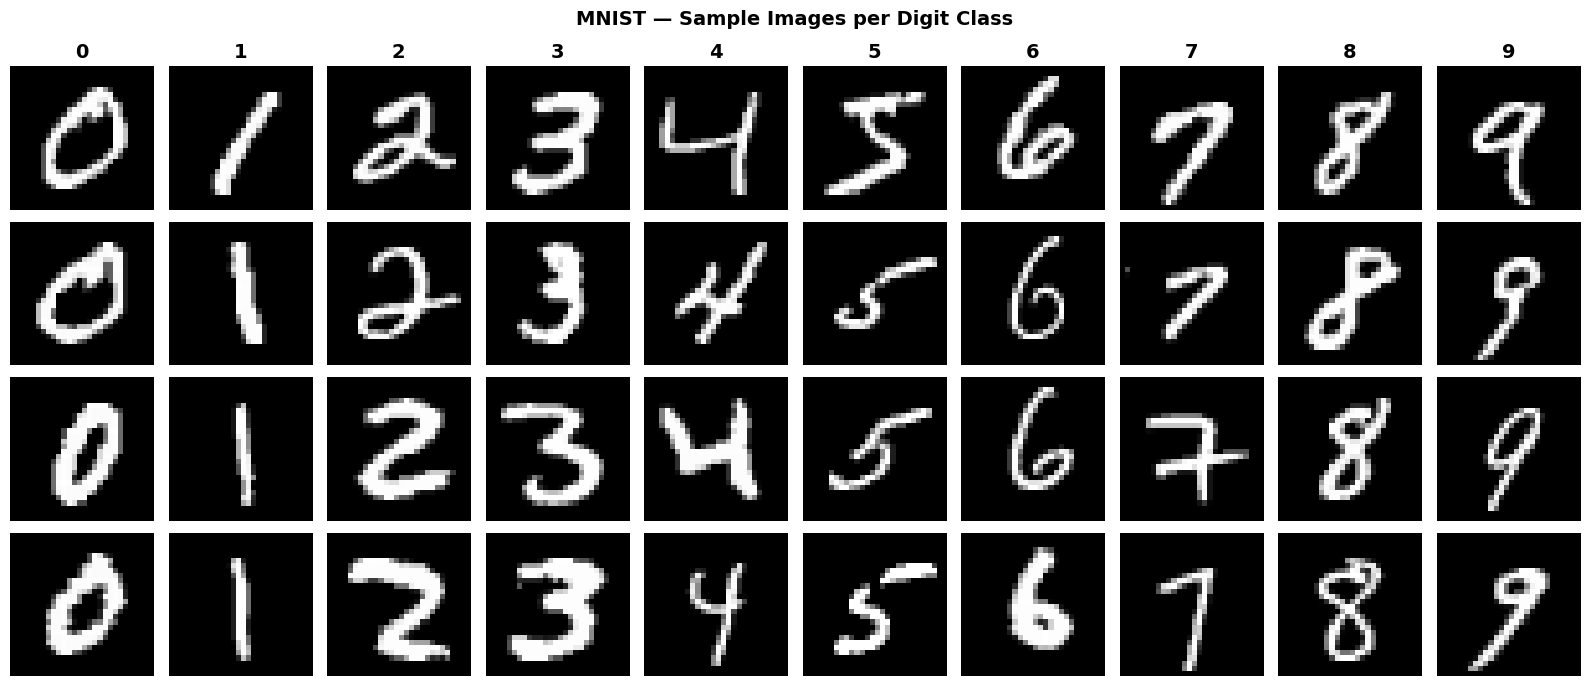

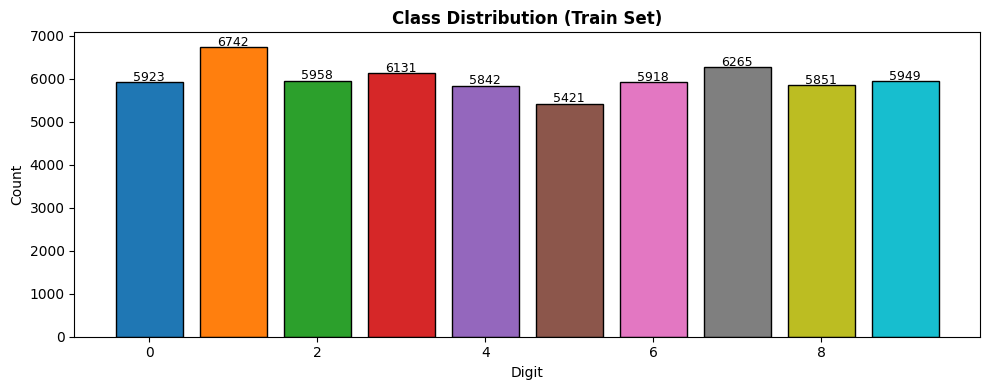

In [3]:
# ─── Visualize Sample Images ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for digit in range(10):
    idx = np.where(y_train == digit)[0][:4]
    for row, i in enumerate(idx):
        axes[row, digit].imshow(X_train[i], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=14, fontweight='bold')

plt.suptitle('MNIST — Sample Images per Digit Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Class distribution
plt.figure(figsize=(10, 4))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black')
plt.title('Class Distribution (Train Set)', fontweight='bold')
plt.xlabel('Digit'); plt.ylabel('Count')
for u, c in zip(unique, counts):
    plt.text(u, c + 30, str(c), ha='center', fontsize=9)
plt.tight_layout(); plt.show()


In [4]:
# ─── Preprocessing ───────────────────────────────────────────────────────────
# Normalize & reshape
X_train_n = X_train.astype('float32') / 255.0
X_test_n  = X_test.astype('float32')  / 255.0

X_train_n = X_train_n.reshape(-1, 28, 28, 1)
X_test_n  = X_test_n.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)

# Data augmentation (prevents overfitting)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(X_train_n)

print(f"X_train shape: {X_train_n.shape}")
print(f"X_test  shape: {X_test_n.shape}")
print("✅ Preprocessing complete. Data augmentation enabled.")


X_train shape: (60000, 28, 28, 1)
X_test  shape: (10000, 28, 28, 1)
✅ Preprocessing complete. Data augmentation enabled.


In [5]:
# ─── Build CNN Architecture ──────────────────────────────────────────────────
def build_cnn_mnist():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.3),

        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_mnist()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
# ─── Train the Model ─────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

history = model.fit(
    datagen.flow(X_train_n, y_train_oh, batch_size=128),
    steps_per_epoch=len(X_train_n) // 128,
    epochs=30,
    validation_data=(X_test_n, y_test_oh),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - accuracy: 0.8839 - loss: 0.3767 - val_accuracy: 0.8878 - val_loss: 0.3209 - learning_rate: 0.0010
Epoch 2/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9531 - loss: 0.1422 - val_accuracy: 0.8863 - val_loss: 0.3261 - learning_rate: 0.0010
Epoch 3/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9667 - loss: 0.1055 - val_accuracy: 0.9900 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 4/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.0858 - val_accuracy: 0.9898 - val_loss: 0.0321 - learning_rate: 0.0010
Epoch 5/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9760 - loss: 0.0764 - val_accuracy: 0.9883 - val_loss: 0.0329 - learning_rate: 0.0010
Epoch 6/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - loss: 0.0592 - val_accuracy: 0.9882 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 7/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9792 - loss: 0

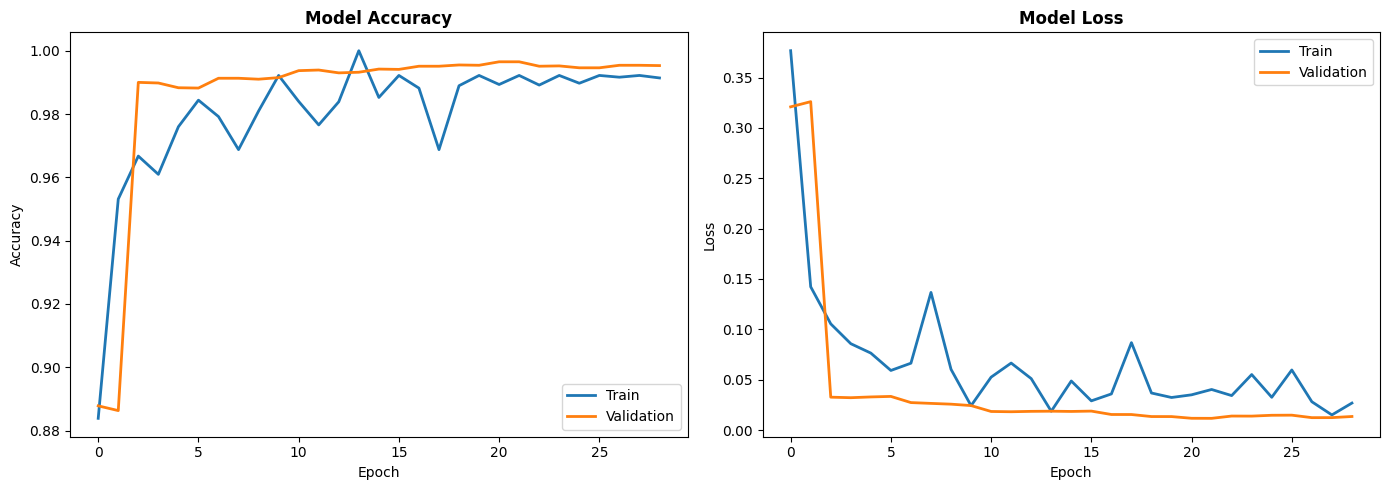

In [7]:
# ─── Training Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     lw=2, label='Train')
axes[0].plot(history.history['val_accuracy'], lw=2, label='Validation')
axes[0].set_title('Model Accuracy', fontweight='bold'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')

axes[1].plot(history.history['loss'],     lw=2, label='Train')
axes[1].plot(history.history['val_loss'], lw=2, label='Validation')
axes[1].set_title('Model Loss', fontweight='bold'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

plt.tight_layout(); plt.show()


In [8]:
# ─── Final Evaluation ────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test_n, y_test_oh, verbose=0)
print(f"\n🏆 Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   Test Loss     : {test_loss:.4f}\n")

y_pred = np.argmax(model.predict(X_test_n, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))



🏆 Test Accuracy : 0.9965  (99.65%)
   Test Loss     : 0.0117

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       1.00      1.00      1.00       892
           6       1.00      1.00      1.00       958
           7       0.99      1.00      0.99      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



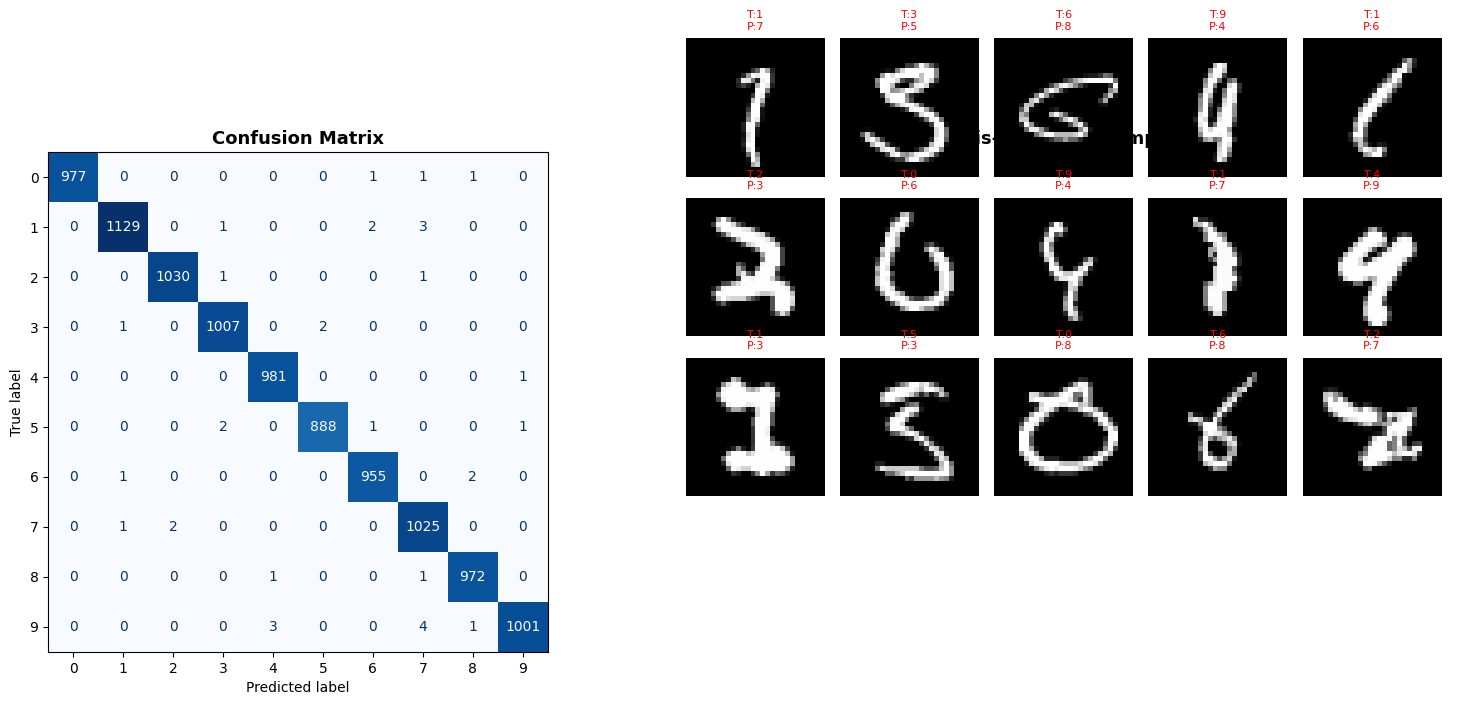

In [9]:
# ─── Confusion Matrix & Mis-classified Samples ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(range(10)),
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# Show mis-classified examples
wrong_idx = np.where(y_pred != y_test)[0][:20]
axes[1].axis('off')
inner = axes[1].inset_axes([0, 0, 1, 1])
inner.axis('off')
for k, idx in enumerate(wrong_idx[:15]):
    r, c = divmod(k, 5)
    ax_ = axes[1].inset_axes([c*0.2, 0.95 - r*0.32, 0.18, 0.28])
    ax_.imshow(X_test[idx], cmap='gray')
    ax_.set_title(f'T:{y_test[idx]}\nP:{y_pred[idx]}', fontsize=8, color='red')
    ax_.axis('off')
axes[1].set_title('Mis-classified Samples', fontweight='bold', fontsize=13, y=1.0)

plt.tight_layout(); plt.show()


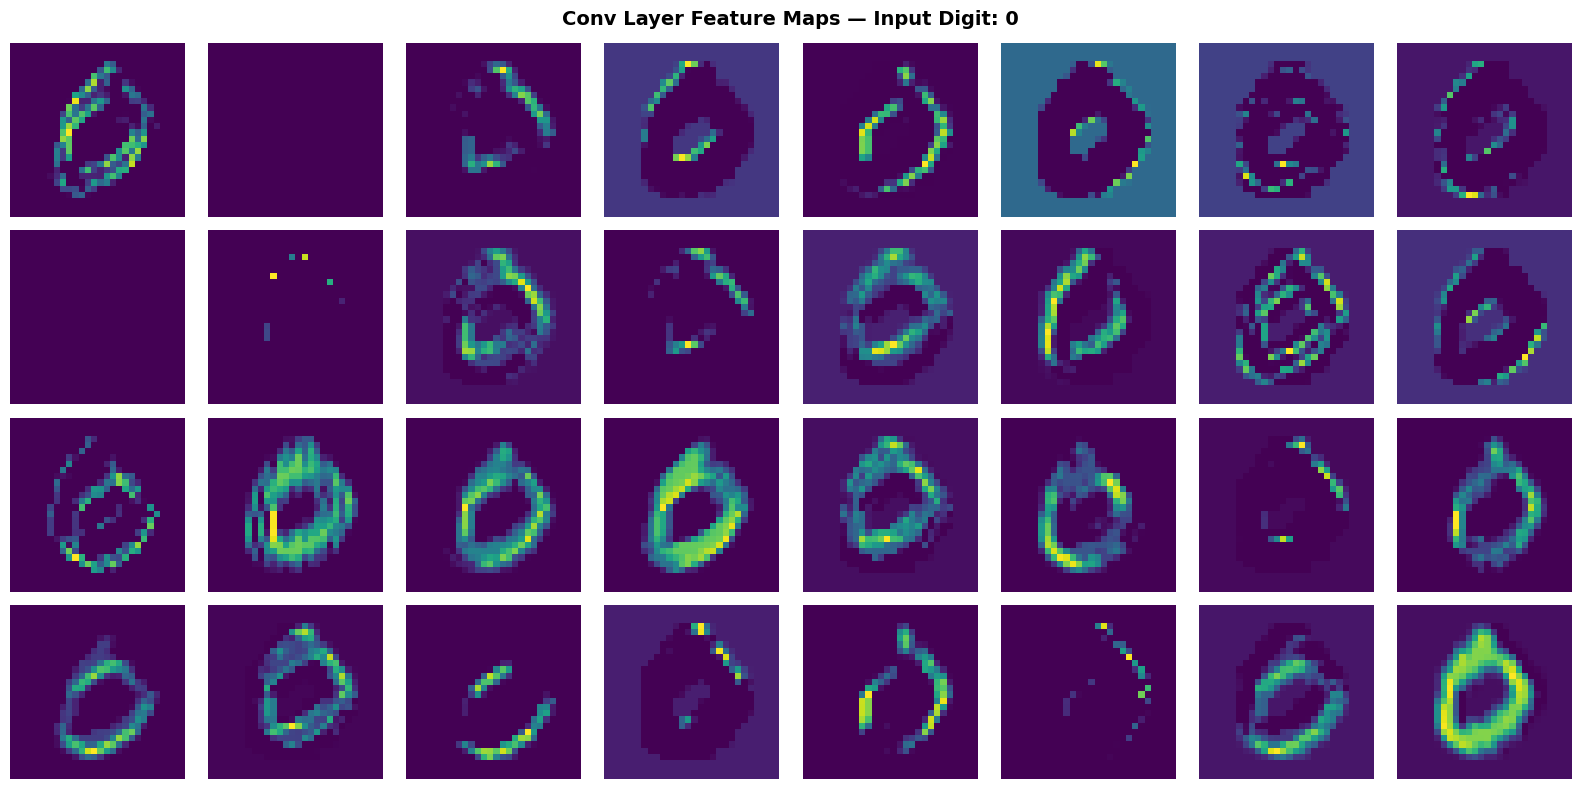


✅ CNN successfully learned spatial features for handwritten digit recognition!


In [15]:
# ─── Visualize CNN Feature Maps ──────────────────────────────────────────────
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input # Need to import Input layer
import tensorflow as tf # Ensure tf is imported for tf.zeros

# The error "AttributeError: The layer sequential has never been called and thus has no defined input."
# indicates that `model.input` is not a symbolic tensor that can be directly used
# to construct a new `Model` via `Model(inputs=model.input, ...)`. This can happen
# with Sequential models even after they have been built or trained.

# To robustly extract feature maps, we will build a new functional model
# that takes a fresh Input tensor and feeds it through the desired layers of the original model.

# 1. Define a new Input tensor with the same shape as the original model's input
input_for_feature_extractor = Input(shape=(28, 28, 1))

# 2. Identify the first convolutional layer in the trained model
layer_names = [layer.name for layer in model.layers if 'conv2d' in layer.name]
first_conv_layer = model.get_layer(layer_names[0])

# 3. Connect the new input tensor to the output of the first convolutional layer
#    by "calling" the convolutional layer with the new input tensor.
#    We must rebuild the layer for the functional API by applying it to the new input.
output_of_first_conv = first_conv_layer(input_for_feature_extractor)

# 4. Create the feature extraction model
feature_map_model = Model(inputs=input_for_feature_extractor, outputs=output_of_first_conv)

sample_img = X_test_n[3:4]      # single test image
feature_maps = feature_map_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle(f'Conv Layer Feature Maps — Input Digit: {y_test[3]}',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n✅ CNN successfully learned spatial features for handwritten digit recognition!")